In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

In [58]:
df = pd.read_csv("dataset/raw/train.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2492196 entries, 0 to 2492195
Data columns (total 28 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ID                 object 
 1   Severity           int64  
 2   Start_Time         object 
 3   End_Time           object 
 4   Latitude           float64
 5   Longitude          float64
 6   Distance(mi)       float64
 7   Description        object 
 8   Street             object 
 9   City               object 
 10  County             object 
 11  State              object 
 12  Zipcode            object 
 13  Timezone           object 
 14  Airport_Code       object 
 15  Weather_Timestamp  object 
 16  Temperature(F)     float64
 17  Humidity(%)        float64
 18  Visibility(mi)     float64
 19  Weather_Condition  object 
 20  Amenity            bool   
 21  Crossing           bool   
 22  Junction           bool   
 23  Railway            bool   
 24  Station            bool   
 25  Stop              

In [10]:
pd.set_option('display.max_columns', None)
df.head()

,ID,Severity,Start_Time,End_Time,Latitude,Longitude,Distance(mi),Description,Street,City,County,State,Zipcode,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Amenity,Crossing,Junction,Railway,Station,Stop,Traffic_Signal,Sunrise_Sunset
0,A-4081224,4,2022-03-18 06:55:00,2022-03-18 11:55:00,36.081864,-79.080223,0.039,The road is closed near St Mary's Rd.,St Marys Rd,Hillsborough,Orange,NC,27278-2524,US/Eastern,KIGX,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,Night
1,A-4338502,2,2023-01-29 16:35:00,2023-01-29 17:53:04,38.927944,-121.056469,0.014,Incident on BOWMAN RD near LUTHER RD Drive wit...,Bowman Rd,Auburn,Placer,CA,95603,US/Pacific,KAUN,2023-01-29 16:35:00,41.0,93.0,10.0,Cloudy,False,False,False,False,False,True,False,Day
2,A-4813526,2,2022-10-11 12:53:40,2022-10-11 14:44:43,37.539693,-77.432146,0.008,Incident on N 11TH ST near E BROAD ST RICH Dri...,E Broad St,Richmond,Richmond City,VA,23219-1908,US/Eastern,KRIC,2022-10-11 12:54:00,71.0,32.0,10.0,Fair,False,True,False,False,False,False,True,Day
3,A-4731406,2,2022-01-24 06:12:00,2022-01-24 06:40:30,36.998262,-76.409113,0.944,Slow traffic on I-664 S from Aberdeen Rd/Exit ...,I-664 S,Newport News,Newport News,VA,23607,US/Eastern,KLFI,2022-01-24 05:56:00,26.0,99.0,10.0,Fair,False,False,True,False,False,False,False,Night
4,A-7263275,2,2020-02-14 15:28:00,2020-02-14 16:26:09,38.524770,-121.467450,0.000,At Fruitridge Rd - Accident.,CA-99 N,Sacramento,Sacramento,CA,95824,US/Pacific,KSAC,2020-02-14 15:53:00,64.0,52.0,10.0,Fair,False,False,True,False,False,False,False,Day


In [12]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()
boolean_vars = ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']

In [14]:
print("\nNumerical Columns:", numerical_vars)
print("\nCategorical Columns:", categorical_vars)
print("\nBoolean Variables:", boolean_vars)


Numerical Columns: ['Severity', 'Latitude', 'Longitude', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)']

Categorical Columns: ['ID', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Weather_Condition', 'Sunrise_Sunset']

Boolean Variables: ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']


In [15]:
numerical_data = df[numerical_vars]
categorical_data = df[categorical_vars]
boolean_data = df[boolean_vars]

In [16]:
for c in categorical_vars:
    col_cnt = categorical_data[c].nunique()
    print(f"{c} has {col_cnt} unique values .")

ID has 2492196 unique values .
Start_Time has 1636474 unique values .
End_Time has 2015570 unique values .
Description has 1150710 unique values .
Street has 176406 unique values .
City has 11521 unique values .
County has 1745 unique values .
State has 49 unique values .
Zipcode has 371313 unique values .
Timezone has 4 unique values .
Airport_Code has 1968 unique values .
Weather_Timestamp has 404043 unique values .
Weather_Condition has 122 unique values .
Sunrise_Sunset has 2 unique values .


In [27]:
# Create a base map
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=10)

# Create a random sample of 200 rows from df
df_sample = df.sample(n=200, random_state=1)

# Add points to the map
for idx, row in df_sample.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Severity']
    ).add_to(m)

# Display the map
m

**Missing Value Detection**

In [19]:
missing_count = missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent}).sort_values(by='Missing Percent', ascending=False)   

,Missing Count,Missing Percent
Humidity(%),65945,2.65
Visibility(mi),64006,2.57
Weather_Condition,62172,2.49
Temperature(F),62100,2.49
Weather_Timestamp,47950,1.92
Sunrise_Sunset,12720,0.51
Airport_Code,9295,0.37
Street,5411,0.22
Timezone,2782,0.11
Zipcode,724,0.03


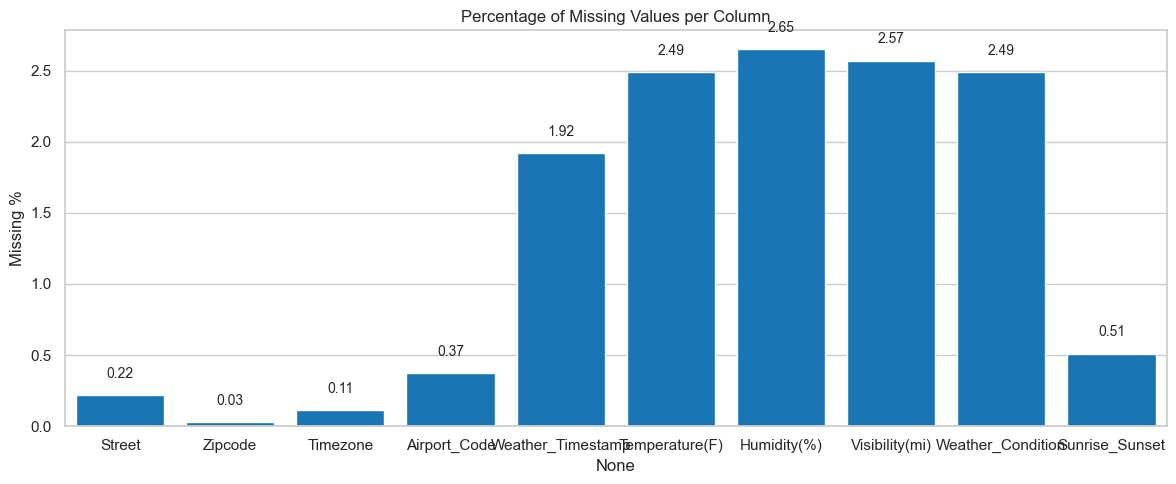

In [42]:
missing_plot = missing_percent[missing_percent > 0] 
plt.figure(figsize=(12,5))
ax = sns.barplot(x=missing_plot.index, y=missing_plot.values, color='#007acc')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0, ha='center')
plt.ylabel('Missing %')
plt.title('Percentage of Missing Values per Column')
plt.tight_layout()
plt.show()

**Leakage check**

In [25]:
target_var = 'Severity'
print("Potential data leakage check:")
print("Columns highly correlated with target may indicate leakage.")
corr_target = df[numerical_vars].corr()[target_var].drop(target_var)
leak_cols = corr_target[abs(corr_target) > 0.9].index.tolist()
if leak_cols:
    print(f"Potential leakage columns (corr > 0.9 with target): {leak_cols}\n")
else:
    print("No obvious leakage columns detected based on correlation.\n")


Potential data leakage check:
Columns highly correlated with target may indicate leakage.
No obvious leakage columns detected based on correlation.



**Outlier Detection**


In [21]:
# Detect outliers using the IQR method
Q1 = df[numerical_vars].quantile(0.25)
Q3 = df[numerical_vars].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical_vars] < (Q1 - 1.5 * IQR)) | 
              (df[numerical_vars] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 Severity          169722
Latitude               0
Longitude              0
Distance(mi)      248427
Temperature(F)     15524
Humidity(%)            0
Visibility(mi)    462310
dtype: int64


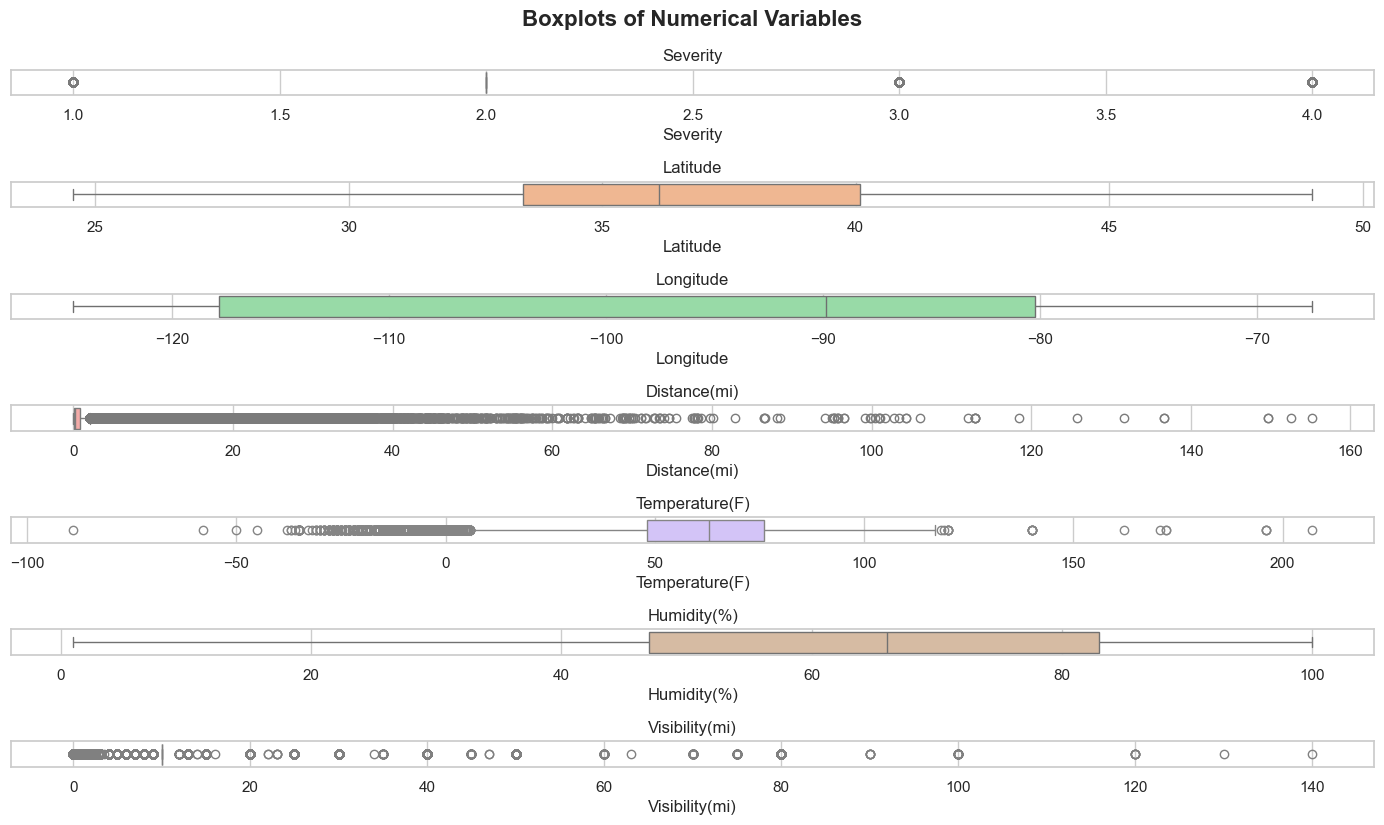

In [22]:
n = len(numerical_vars)

plt.figure(figsize=(14, n * 1.2))
plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_vars, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df[col],
        orient='h',
        color=palette_color[i - 1]
    )
    plt.title(col)
    plt.tight_layout()

plt.show()

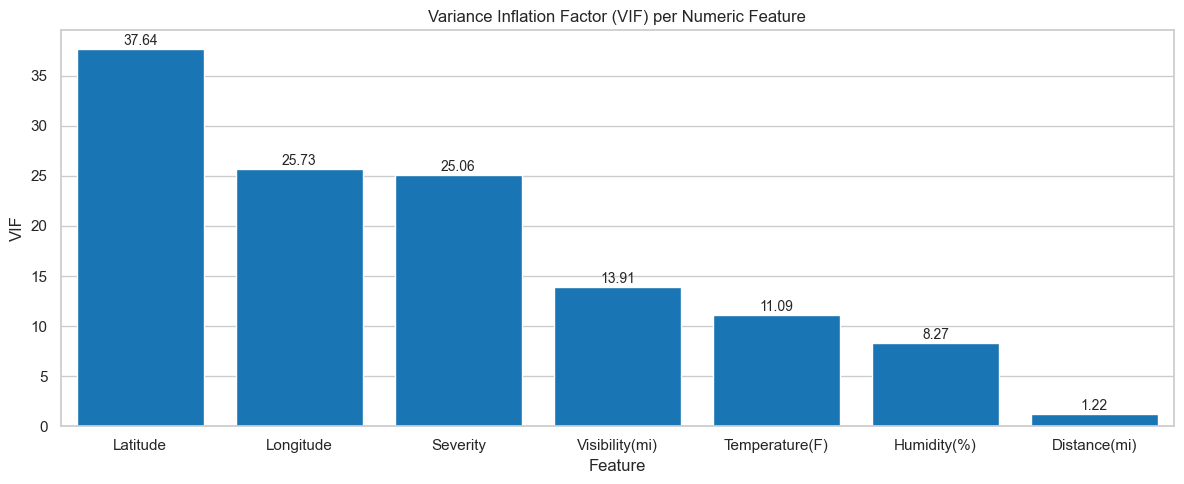

In [43]:
target_var = 'Severity'
X_numeric = df[numerical_vars]

vif_data = pd.DataFrame()
vif_data['Feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.dropna().values, i) 
                   for i in range(X_numeric.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

plt.figure(figsize=(12,5))
ax = sns.barplot(x='Feature', y='VIF', data=vif_data, color='#007acc')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height:.2f}', 
            ha='center', va='bottom', fontsize=10)
    
plt.xticks(rotation=0, ha='center')
plt.ylabel('VIF')
plt.title('Variance Inflation Factor (VIF) per Numeric Feature')
plt.tight_layout()
plt.show()

**Build Baseline Model**

In [59]:
target_var = 'Severity'
y = df[target_var]
X = df.drop(columns=[target_var])

In [60]:
model_results = {}

In [61]:
drop_cols = [
    'ID','Start_Time','End_Time','Description','Street','City','County','State',
    'Zipcode','Timezone','Airport_Code','Weather_Timestamp','Weather_Condition','Sunrise_Sunset'
]

X_model = X.drop(columns=drop_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)


In [67]:
X_train_clean = X_train.dropna()
y_train_clean = y_train[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_clean = y_test[X_test_clean.index]

models_to_evaluate = {
    'XGBoost': {
        'model': XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        'use_clean': False 
    },
    'LightGBM': {
        'model': LGBMRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'use_clean': False
    },
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),
        'use_clean': True  
    },
    'CatBoost': {
        'model': CatBoostRegressor(
            n_estimators=50,
            random_state=42,
            verbose=0
        ),
        'use_clean': True  
    }
}

model_results = []

def evaluate_and_store(model, X_test, y_test, name):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mse = mean_squared_error(y_test, pred)
    rmlse = np.sqrt(mean_squared_log_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    model_results.append({
        "Model": name,
        "RMSE": rmse,
        "RMLSE": rmlse,
        "MSE": mse,
        "R2": r2
    })

for name, cfg in models_to_evaluate.items():
    print(f"Training {name}...")
    model = cfg['model']
    
    if cfg.get('use_clean', False):
        model.fit(X_train_clean, y_train_clean)
        evaluate_and_store(model, X_test_clean, y_test_clean, name)
    else:
        model.fit(X_train, y_train)
        evaluate_and_store(model, X_test, y_test, name)

results_df = pd.DataFrame(model_results)
print("\nModel Evaluation Results:")
print(results_df.sort_values(by='RMSE'))


Training XGBoost...
Training LightGBM...
Training Random Forest...
Training CatBoost...

Model Evaluation Results:
           Model      RMSE     RMLSE       MSE        R2
2  Random Forest  0.379298  0.102062  0.143867  0.119262
3       CatBoost  0.380846  0.102613  0.145044  0.112057
1       LightGBM  0.383945  0.103243  0.147413  0.104721
0        XGBoost  0.384437  0.103413  0.147792  0.102422
